# * Top-k Micro-level SHAP Analysis on Full 660-dim Raw Feature Space
---
**Research Goal**: Bổ sung phân tích SHAP đa cấp độ — giữ lại SHAP gộp 3 nhóm (Macro) và mở rộng xuống cấp độ đặc trưng thô (Micro) để xác định SKU/biến hệ thống nào ảnh hưởng mạnh nhất đến quyết định của Agent.

**Khung lý thuyết**:
- **Macro SHAP** (kế thừa từ ablation_SHAP.ipynb): 3 features tổng hợp [Inventory, Sales, Waste] → khung định hướng chiến lược cho nhà quản trị
- **Top-k Micro SHAP** (bổ sung): 660 features gốc (220 SKU × 3 features) → xác định chính xác SKU nào dẫn dắt quyết định

**Agents**: DQN (Double DQN, Per-Product Q-Network) vs A2C_mod (Actor-Critic)
**Environment**: 220 products, 14 discrete actions
**Test states**: 50 states per scenario (EASY/MEDIUM/HARD)

---

## * Tại sao vẫn giữ SHAP gộp 3 nhóm?

1. **Tính chiến lược (Strategic Framework)**: 3 nhóm vĩ mô (Inventory, Demand, Waste) cung cấp cái nhìn tổng quan, giúp nhà quản trị nhận diện nhanh xu hướng hành vi tổng thể của Agent mà không bị quá tải thông tin.
2. **Tính tương thích (Compatibility)**: Duy trì tính nhất quán với các phân tích trước (FCS, ablation study), cho phép so sánh trực tiếp kết quả.
3. **Bổ sung (Not Replacement)**: Top-k Micro SHAP **bổ sung** chứ không thay thế — giải quyết câu hỏi "SKU nào?" trong khi Macro SHAP giải quyết câu hỏi "Nhóm nào?".

> **Thừa nhận hạn chế**: Việc gộp 660 chiều trạng thái thành 3 đặc trưng vĩ mô làm **mất thông tin cấp sản phẩm (SKU-level heterogeneity)**. Một feature có thể quan trọng ở cấp vĩ mô nhưng không phải SKU nào cũng đóng góp như nhau. Top-k Micro SHAP khắc phục điều này bằng cách phân tích từng chiều gốc.

### Công thức tính độ quan trọng của từng feature:
$$I_{Micro}(f_j) = \frac{1}{N \cdot A} \sum_{n=1}^{N} \sum_{a=1}^{A} |\phi_{j,a}^{(n)}|$$

Trong đó:
- $f_j$: feature thứ $j$ trong 660 features gốc
- $\phi_{j,a}^{(n)}$: SHAP value của feature $j$ cho action $a$ tại state $n$
- $N$: số test states (50)
- $A$: số actions (14)

## Step 0: Setup & Khởi tạo Agent (Restore Checkpoints)

In [1]:
import os, warnings, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

np.set_printoptions(edgeitems=10, linewidth=10000, precision=6, suppress=True)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print(f'TensorFlow: {tf.__version__}')
print(f'NumPy: {np.__version__}')
print(f'SHAP: {shap.__version__}')
print(f'Device: {"GPU" if tf.config.list_physical_devices("GPU") else "CPU"}')

TensorFlow: 2.20.0
NumPy: 2.4.2
SHAP: 0.50.0
Device: CPU


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
NUM_PRODUCTS    = 220
NUM_FEATURES_PP = 3          # per product: [x, sales, q]
NUM_FEATURES    = NUM_PRODUCTS * NUM_FEATURES_PP  # 660
NUM_ACTIONS     = 14
ACTION_SPACE    = np.array([0, 0.005, 0.01, 0.0125, 0.015, 0.0175,
                            0.02, 0.03, 0.04, 0.08, 0.12, 0.2, 0.5, 1],
                           dtype=np.float32)
WASTE_RATE      = 0.025
ZERO_INVENTORY  = 1e-5
GAMMA           = 0.99

# Architecture sizes
DQN_HIDDEN  = 32
A2C_HIDDEN  = 32
DROPOUT     = 0.1

# Paths
DATA_DIR        = r'C:\NCKH\SHAP\data'
TEST_FILE       = os.path.join(DATA_DIR, 'test.tfrecords')
CAP_FILE        = os.path.join(DATA_DIR, 'capacity.tfrecords')
STOCK_FILE      = os.path.join(DATA_DIR, 'stock.tfrecords')
DQN_CKPT_DIR    = r'C:\NCKH\SHAP\checkpoints_dqn_comparison512_32'
A2C_CKPT_DIR    = r'C:\NCKH\SHAP\outputA2Cmod\checkpoints_a2cmod'

# Feature identifiers
FEATURES_MACRO = ['inventory', 'sales', 'waste_feat']  # 3 macro groups

# Feature mapping: indices 0-219 = inventory, 220-439 = sales, 440-659 = waste
def get_feature_info(idx):
    if idx < NUM_PRODUCTS:
        return ('inventory', idx)
    elif idx < 2 * NUM_PRODUCTS:
        return ('sales', idx - NUM_PRODUCTS)
    else:
        return ('waste_feat', idx - 2 * NUM_PRODUCTS)

FEATURE_NAMES_660 = [f'{get_feature_info(i)[0]}_SKU{get_feature_info(i)[1]}' for i in range(NUM_FEATURES)]
FEATURE_GROUPS_660 = [get_feature_info(i)[0] for i in range(NUM_FEATURES)]
FEATURE_SKU_IDS   = [get_feature_info(i)[1] for i in range(NUM_FEATURES)]

print('Configuration [OK]')
print(f'  NUM_FEATURES = {NUM_FEATURES} ({NUM_PRODUCTS} products x {NUM_FEATURES_PP} features)')
print(f'  Data directory: {DATA_DIR}')
print(f'  DQN checkpoints: {DQN_CKPT_DIR}')
print(f'  A2C checkpoints: {A2C_CKPT_DIR}')

Configuration [OK]
  NUM_FEATURES = 660 (220 products x 3 features)
  Data directory: C:\NCKH\SHAP\data
  DQN checkpoints: C:\NCKH\SHAP\checkpoints_dqn_comparison512_32
  A2C checkpoints: C:\NCKH\SHAP\outputA2Cmod\checkpoints_a2cmod


In [3]:
# ============================================================
# A2C_mod Model Classes
# ============================================================
class Dense(tf.Module):
    def __init__(self, input_dim, output_size, activation=None, stddev=1.0):
        super(Dense, self).__init__()
        self.w = tf.Variable(
            tf.random.truncated_normal([input_dim, output_size], stddev=stddev), name='w')
        self.b = tf.Variable(tf.zeros([output_size]), name='b')
        self.activation = activation

    def __call__(self, x):
        y = tf.matmul(x, self.w) + self.b
        if self.activation:
            y = self.activation(y)
        return y

class Actor(tf.Module):
    def __init__(self, num_features, num_actions, hidden_size,
                 activation=tf.nn.relu, dropout_prob=0.1):
        super(Actor, self).__init__()
        self.layer1 = Dense(num_features, hidden_size, activation=None)
        self.layer2 = Dense(hidden_size, hidden_size, activation=None)
        self.layer3 = Dense(hidden_size, hidden_size, activation=None)
        self.layer4 = Dense(hidden_size, num_actions, activation=None)
        self.activation = activation
        self.dropout_prob = dropout_prob

    def __call__(self, state):
        x = self.activation(self.layer1(state))
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.activation(self.layer2(x))
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.activation(self.layer3(x))
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.layer4(x)
        return tf.nn.softmax(x)

class Critic(tf.Module):
    def __init__(self, num_features, hidden_size,
                 activation=tf.nn.relu, dropout_prob=0.1):
        super(Critic, self).__init__()
        self.layer1 = Dense(num_features, hidden_size, activation=None)
        self.layer2 = Dense(hidden_size, 1, activation=None)
        self.activation = activation
        self.dropout_prob = dropout_prob
        self.group_norm = tf.keras.layers.GroupNormalization(groups=1)

    def __call__(self, state):
        x = self.layer1(state)
        x = self.group_norm(x)
        x = self.activation(x)
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.layer2(x)
        return tf.squeeze(x, axis=-1, name='factor_squeeze')

print('A2C_mod classes defined OK')

A2C_mod classes defined OK


In [4]:
# ============================================================
# DQN Model Class
# ============================================================
class MultiProductQNetwork(tf.keras.Model):
    def __init__(self, num_features, num_products, num_actions,
                 hidden_size, dropout_prob=0.1, use_group_norm=True, name=None):
        super().__init__(name=name)
        self.num_products      = num_products
        self.num_actions       = num_actions
        self.features_per_prod = num_features // num_products

        self.dense1 = tf.keras.layers.Dense(hidden_size, activation=None, name='dense1')
        self.dense2 = tf.keras.layers.Dense(hidden_size, activation=None, name='dense2')
        self.dense3 = tf.keras.layers.Dense(hidden_size, activation=None, name='dense3')
        self.out    = tf.keras.layers.Dense(num_actions,  activation=None, name='output')

        self._use_gn = use_group_norm
        if use_group_norm:
            self.gn1 = tf.keras.layers.GroupNormalization(groups=1, name='gn1')
            self.gn2 = tf.keras.layers.GroupNormalization(groups=1, name='gn2')
            self.gn3 = tf.keras.layers.GroupNormalization(groups=1, name='gn3')

        self.drop1 = tf.keras.layers.Dropout(dropout_prob)
        self.drop2 = tf.keras.layers.Dropout(dropout_prob)
        self.drop3 = tf.keras.layers.Dropout(dropout_prob)

    def call(self, state, training=False):
        B = tf.shape(state)[0]
        P, F = self.num_products, self.features_per_prod
        s3d = tf.transpose(tf.reshape(state, [B, F, P]), [0, 2, 1])
        x = tf.reshape(s3d, [B * P, F])
        x = self.dense1(x)
        if self._use_gn: x = self.gn1(x, training=training)
        x = tf.nn.relu(x); x = self.drop1(x, training=training)
        x = self.dense2(x)
        if self._use_gn: x = self.gn2(x, training=training)
        x = tf.nn.relu(x); x = self.drop2(x, training=training)
        x = self.dense3(x)
        if self._use_gn: x = self.gn3(x, training=training)
        x = tf.nn.relu(x); x = self.drop3(x, training=training)
        return tf.reshape(self.out(x), [B, P, self.num_actions])

print('DQN class (MultiProductQNetwork) defined OK')

DQN class (MultiProductQNetwork) defined OK


In [5]:
# ============================================================
# Load Checkpoints
# ============================================================
def load_trained_agents():
    actor  = Actor(NUM_FEATURES_PP, NUM_ACTIONS, A2C_HIDDEN,
                   activation=tf.nn.relu, dropout_prob=DROPOUT)
    critic = Critic(NUM_FEATURES_PP, A2C_HIDDEN,
                    activation=tf.nn.relu, dropout_prob=DROPOUT)
    _d = tf.zeros([1, NUM_FEATURES_PP])
    _ = actor(_d); _ = critic(_d)

    a2c_ckpt = tf.train.Checkpoint(
        critic_optimizer=tf.optimizers.Adam(0.0005),
        actor_optimizer=tf.optimizers.Adam(0.0001),
        critic=critic, actor=actor, step=tf.Variable(0))
    a2c_ckpt.restore(tf.train.latest_checkpoint(A2C_CKPT_DIR)).expect_partial()
    print('OK A2C_mod restored:', tf.train.latest_checkpoint(A2C_CKPT_DIR))

    q_net = MultiProductQNetwork(
        NUM_FEATURES, NUM_PRODUCTS, NUM_ACTIONS,
        DQN_HIDDEN, DROPOUT, use_group_norm=True, name='q_network')
    t_net = MultiProductQNetwork(
        NUM_FEATURES, NUM_PRODUCTS, NUM_ACTIONS,
        DQN_HIDDEN, DROPOUT, use_group_norm=True, name='target_network')
    _d = tf.zeros([1, NUM_FEATURES], dtype=tf.float32)
    _ = q_net(_d, training=False); _ = t_net(_d, training=False)

    dqn_ckpt = tf.train.Checkpoint(
        optimizer=tf.optimizers.Adam(0.001),
        q_network=q_net, target_network=t_net,
        step=tf.Variable(0, dtype=tf.int64))
    dqn_ckpt.restore(tf.train.latest_checkpoint(DQN_CKPT_DIR)).expect_partial()
    print('OK DQN restored:', tf.train.latest_checkpoint(DQN_CKPT_DIR))

    return {'actor': actor, 'critic': critic, 'q_network': q_net}

agents = load_trained_agents()

OK A2C_mod restored: C:\NCKH\SHAP\outputA2Cmod\checkpoints_a2cmod\ckpt-64
OK DQN restored: C:\NCKH\SHAP\checkpoints_dqn_comparison512_32\ckpt-43


In [6]:
# ============================================================
# Load Test Data from TFRecords
# ============================================================
def _parse(serialized, key, n):
    return tf.io.parse_single_example(
        serialized, {key: tf.io.FixedLenFeature([n], tf.float32)})[key]

capacity = next(iter(
    tf.data.TFRecordDataset(CAP_FILE).map(lambda s: _parse(s, 'capacity', NUM_PRODUCTS))
)).numpy()

x_init = next(iter(
    tf.data.TFRecordDataset(STOCK_FILE).map(lambda s: _parse(s, 'stock', NUM_PRODUCTS))
)).numpy()

all_sales = []
for rec in tf.data.TFRecordDataset(TEST_FILE).map(lambda s: _parse(s, 'sales', NUM_PRODUCTS)):
    all_sales.append(rec.numpy())
all_sales = np.array(all_sales, dtype=np.float32) / capacity[None, :]
T_MAX = len(all_sales)

print(f'OK Test data loaded: {T_MAX} timesteps x {NUM_PRODUCTS} products')
print(f'   Capacity shape: {capacity.shape}')
print(f'   Initial stock shape: {x_init.shape}')

OK Test data loaded: 504 timesteps x 220 products
   Capacity shape: (220,)
   Initial stock shape: (220,)


---
## Step 1: Tao 660-dim Background & Test States
---

**Giai thich**: 
- Thay vi gop 220 san pham thanh 3 features tong hop, ta giu nguyen cau truc 660 chieu (inventory_0..219, sales_0..219, waste_0..219)
- Background data (~100 mau) mo phong phan phoi thuc te cho tung SKU
- Test states (~50 mau) duoc trich tu TFRecord that, scale theo tung scenario (EASY/MEDIUM/HARD)

In [7]:
# ============================================================
# Parameters
# ============================================================
NUM_TEST_STATES = 50     # ~50 states per scenario (Option 2)
NUM_BG_SAMPLES  = 100    # background samples for SHAP

SCENARIOS = {
    'EASY':   {'sales_scale': 0.5,  'waste_rate': 0.010, 'label': 'De'},
    'MEDIUM': {'sales_scale': 1.0,  'waste_rate': 0.025, 'label': 'Trung binh'},
    'HARD':   {'sales_scale': 1.5,  'waste_rate': 0.050, 'label': 'Kho'},
}
SCENARIO_ORDER = ['EASY', 'MEDIUM', 'HARD']

print(f'Parameters:')
print(f'  NUM_TEST_STATES = {NUM_TEST_STATES}')
print(f'  NUM_BG_SAMPLES  = {NUM_BG_SAMPLES}')
print(f'  Scenarios: {list(SCENARIOS.keys())}')

Parameters:
  NUM_TEST_STATES = 50
  NUM_BG_SAMPLES  = 100
  Scenarios: ['EASY', 'MEDIUM', 'HARD']


In [8]:
# ============================================================
# Generate 660-dim Background Data
# ============================================================
def generate_background_660(num_samples=NUM_BG_SAMPLES):
    """Tao background data trong khong gian 660 chieu goc."""
    bg = np.zeros((num_samples, NUM_FEATURES), dtype=np.float32)
    bg[:, :NUM_PRODUCTS] = np.random.uniform(0.0, 1.0, size=(num_samples, NUM_PRODUCTS))
    bg[:, NUM_PRODUCTS:2*NUM_PRODUCTS] = np.random.uniform(0.0, 1.0, size=(num_samples, NUM_PRODUCTS))
    waste_noise = np.random.normal(0, 0.005, size=(num_samples, NUM_PRODUCTS))
    bg[:, 2*NUM_PRODUCTS:] = np.clip(
        WASTE_RATE * bg[:, :NUM_PRODUCTS] + waste_noise, 0, 0.1)
    return bg

background_660 = generate_background_660(NUM_BG_SAMPLES)
print(f'OK Background 660-dim: {background_660.shape}')
print(f'   Range: [{background_660.min():.4f}, {background_660.max():.4f}]')

OK Background 660-dim: (100, 660)
   Range: [0.0000, 0.9999]


In [9]:
# ============================================================
# Create 660-dim Test States from Actual Data
# ============================================================
def create_test_states_660(scenario_name, num_states=NUM_TEST_STATES):
    """Tao test states 660 chieu tu du lieu TFRecord that."""
    config = SCENARIOS[scenario_name]
    sales_scale = config['sales_scale']
    waste_rate = config['waste_rate']
    test_sales = all_sales[:num_states, :] * sales_scale
    state_660 = np.zeros((num_states, NUM_FEATURES), dtype=np.float32)
    state_660[:, :NUM_PRODUCTS]          = x_init[None, :]
    state_660[:, NUM_PRODUCTS:2*NUM_PRODUCTS] = test_sales
    state_660[:, 2*NUM_PRODUCTS:]        = x_init[None, :] * waste_rate
    return state_660

test_states_660 = {}
for sc in SCENARIO_ORDER:
    s660 = create_test_states_660(sc, NUM_TEST_STATES)
    test_states_660[sc] = s660
    print(f'OK {sc:6s}: 660-dim {s660.shape}')
    print(f'       Range inv [{s660[:,:NUM_PRODUCTS].min():.3f}, {s660[:,:NUM_PRODUCTS].max():.3f}]')
    print(f'       Range sales [{s660[:,NUM_PRODUCTS:2*NUM_PRODUCTS].min():.3f}, {s660[:,NUM_PRODUCTS:2*NUM_PRODUCTS].max():.3f}]')

OK EASY  : 660-dim (50, 660)
       Range inv [0.007, 0.990]
       Range sales [0.000, 0.625]
OK MEDIUM: 660-dim (50, 660)
       Range inv [0.007, 0.990]
       Range sales [0.000, 1.250]
OK HARD  : 660-dim (50, 660)
       Range inv [0.007, 0.990]
       Range sales [0.000, 1.875]


---
## Step 2: Predict Wrappers cho Full 660-dim Input
---

**Giai thich**:
- **DQN**: Model da nhan `(batch, 660)` -> `(batch, 220, 14)`. Them wrapper lay mean Q-values qua 220 products -> `(batch, 14)`.
- **A2C**: Actor chi nhan `(batch, 3)` vi `layer1.w` co shape `(3, 32)`. Ta reshape `(batch, 660)` -> `(batch*220, 3)`, chay actor song song, reshape lai `(batch, 220, 14)`, lay mean -> `(batch, 14)`.

In [10]:
# ============================================================
# DQN Predict Wrapper - Full 660-dim
# ============================================================
def dqn_predict_660(X):
    """DQN forward pass on full 660-dim state."""
    if not isinstance(X, np.ndarray):
        X = np.array(X, dtype=np.float32)
    q_values = agents['q_network'](X, training=False)
    q_mean = tf.reduce_mean(q_values, axis=1)
    return q_mean.numpy()

test_in = np.random.randn(4, NUM_FEATURES).astype(np.float32)
print(f'OK DQN 660 wrapper: input {test_in.shape} -> output {dqn_predict_660(test_in).shape}')

OK DQN 660 wrapper: input (4, 660) -> output (4, 14)


In [11]:
# ============================================================
# A2C Predict Wrapper - Full 660-dim (Per-Product Parallel)
# ============================================================
def a2c_predict_660(X):
    """
    A2C forward pass on full 660-dim state.
    Reshape (B,660) -> (B,220,3) -> actor(per-product) -> mean -> (B,14)
    """
    if not isinstance(X, np.ndarray):
        X = np.array(X, dtype=np.float32)
    B = X.shape[0]
    P, F = NUM_PRODUCTS, NUM_FEATURES_PP
    s3d = tf.transpose(tf.reshape(X, [B, F, P]), [0, 2, 1])
    s_pp = tf.reshape(s3d, [B * P, F])
    probs = agents['actor'](s_pp)
    probs_3d = tf.reshape(probs, [B, P, -1])
    probs_mean = tf.reduce_mean(probs_3d, axis=1)
    return probs_mean.numpy()

print(f'OK A2C 660 wrapper: input {test_in.shape} -> output {a2c_predict_660(test_in).shape}')

OK A2C 660 wrapper: input (4, 660) -> output (4, 14)


---
## Step 3: Setup PartitionExplainer voi Feature Hierarchy
---

**Giai thich**:
- `PartitionExplainer` tan dung cau truc phan cap cua features de tinh SHAP nhanh hon `KernelExplainer`.
- 660 features duoc nhom thanh 3 cluster tu nhien (inventory, sales, waste) - moi cluster 220 features.
- `shap.maskers.Partition` tu dong hoc partition tree tu background data thong qua hierarchical clustering.
- **Uoc tinh thoi gian**: ~5-10 phut cho moi config (2 agents x 3 scenarios = 6 configs).

In [12]:
# ============================================================
# Initialize PartitionExplainer for DQN
# ============================================================
print('Initializing DQN PartitionExplainer...')
print(f'  Background: {background_660.shape}')
print(f'  Clustering 660 features... (may take 1-2 min)')

masker_dqn = shap.maskers.Partition(background_660, max_samples=NUM_BG_SAMPLES)
explainer_dqn_660 = shap.PartitionExplainer(dqn_predict_660, masker_dqn)

print('OK DQN PartitionExplainer ready')
ev = explainer_dqn_660.expected_value
print(f'   Expected value type: {type(ev).__name__}', end='')
if isinstance(ev, list):
    print(f' (len={len(ev)})')
else:
    print(f' shape={np.array(ev).shape}')

Initializing DQN PartitionExplainer...
  Background: (100, 660)
  Clustering 660 features... (may take 1-2 min)
OK DQN PartitionExplainer ready
   Expected value type: NoneType shape=()


In [13]:
# ============================================================
# Initialize PartitionExplainer for A2C
# ============================================================
print('Initializing A2C PartitionExplainer...')

masker_a2c = shap.maskers.Partition(background_660, max_samples=NUM_BG_SAMPLES)
explainer_a2c_660 = shap.PartitionExplainer(a2c_predict_660, masker_a2c)

print('OK A2C PartitionExplainer ready')
ev = explainer_a2c_660.expected_value
if isinstance(ev, list):
    print(f'   Expected value: list(len={len(ev)})')
else:
    print(f'   Expected value shape: {np.array(ev).shape}')

Initializing A2C PartitionExplainer...
OK A2C PartitionExplainer ready
   Expected value shape: ()


---
## Step 4: Compute SHAP Values tren 660-dim Space
---

**Giai thich**:
- Tinh SHAP values cho tat ca 660 features tren ~50 test states x 3 scenarios x 2 agents
- Ket qua tra ve: list of 14 arrays (1 per action), moi array shape `(n_states, 660)`
- Tinh mean |SHAP| = trung binh |SHAP| qua ca actions va states -> (660,) vector importance

**Uoc tinh thoi gian**: ~5-10 phut/config -> tong ~30-60 phut cho 6 configs

In [14]:
# ============================================================
# Compute SHAP Values for All Configurations
# ============================================================
shap_results_660 = {agent: {sc: None for sc in SCENARIO_ORDER}
                    for agent in ['DQN', 'A2C_mod']}

print('='*80)
print('COMPUTING SHAP VALUES ON FULL 660-DIM SPACE')
print('='*80)
print(f'  Configs: 2 agents x 3 scenarios = 6 runs')
print(f'  Each run: {NUM_TEST_STATES} states x 660 features x 14 actions')
print()

for agent_name, explainer in [('DQN', explainer_dqn_660), ('A2C_mod', explainer_a2c_660)]:
    print(f'--- Agent: {agent_name} ---')
    for sc in SCENARIO_ORDER:
        print(f'  Scenario: {sc} ({NUM_TEST_STATES} states)... ', end='')
        start = time.time()

        # Compute SHAP values
        # SHAP 0.52+ PartitionExplainer returns Explanation object
        sv_result = explainer(test_states_660[sc])
        if hasattr(sv_result, "values"):
            sv_array = sv_result.values
        elif isinstance(sv_result, list):
            sv_array = np.stack(sv_result, axis=-1)
        else:
            sv_array = np.array(sv_result)

        # Average |SHAP| across actions + states -> (660,)
        shap_abs_mean = np.mean(np.abs(sv_array), axis=(0, 2))

        shap_results_660[agent_name][sc] = {
            'shap_values': sv_array,
            'shap_importance': shap_abs_mean,
        }
        elapsed = time.time() - start
        print(f'done ({elapsed:.1f}s)')
        print(f'    SHAP shape: {sv_array.shape}')
        print(f'    |SHAP| range: [{shap_abs_mean.min():.6f}, {shap_abs_mean.max():.6f}]')

print()
print('OK SHAP computation on 660-dim complete!')


COMPUTING SHAP VALUES ON FULL 660-DIM SPACE
  Configs: 2 agents x 3 scenarios = 6 runs
  Each run: 50 states x 660 features x 14 actions

--- Agent: DQN ---
  Scenario: EASY (50 states)... 

PartitionExplainer explainer: 51it [10:12, 12.26s/it]                        


done (613.0s)
    SHAP shape: (50, 660, 14)
    |SHAP| range: [0.000799, 0.002808]
  Scenario: MEDIUM (50 states)... 

PartitionExplainer explainer: 51it [06:50,  8.39s/it]                        


done (411.0s)
    SHAP shape: (50, 660, 14)
    |SHAP| range: [0.000764, 0.002744]
  Scenario: HARD (50 states)... 

...

done (234.9s)
    SHAP shape: (50, 660, 14)
    |SHAP| range: [0.000105, 0.000441]
  Scenario: MEDIUM (50 states)... 

PartitionExplainer explainer: 51it [04:29,  5.62s/it]                        


done (269.7s)
    SHAP shape: (50, 660, 14)
    |SHAP| range: [0.000099, 0.000406]
  Scenario: HARD (50 states)... 

PartitionExplainer explainer: 51it [04:21,  5.34s/it]                        

done (261.9s)
    SHAP shape: (50, 660, 14)
    |SHAP| range: [0.000093, 0.000392]

OK SHAP computation on 660-dim complete!


---
## Step 5: Top-k Feature Analysis & Bang So sanh 2 Cap SHAP
---

**Giai thich**:
- Voi moi config, sap xep 660 features theo $I_{Micro}(f_j) = mean|SHAP|$ giam dan
- Lay Top-20 features quan trong nhat
- Xac dinh: feature thuoc macro group nao? SKU nao? y nghia business la gi?
- Lap bang so sanh 2 cap SHAP de thay su khac biet giua macro va micro analysis

In [15]:
# ============================================================
# Bang so sanh 2 cap SHAP Analysis
# ============================================================
comparison_rows = []

for agent_name in ['DQN', 'A2C_mod']:
    for sc in SCENARIO_ORDER:
        data = shap_results_660[agent_name][sc]

        # Macro SHAP: tinh lai bang cach lay TB cac features trong moi nhom
        inv_imp = np.mean(data['shap_importance'][:NUM_PRODUCTS])
        sal_imp = np.mean(data['shap_importance'][NUM_PRODUCTS:2*NUM_PRODUCTS])
        was_imp = np.mean(data['shap_importance'][2*NUM_PRODUCTS:])
        macro_arr = np.array([inv_imp, sal_imp, was_imp])

        # Micro Top-5 features
        top5_idx = np.argsort(data['shap_importance'])[-5:][::-1]
        top5_names = [FEATURE_NAMES_660[i] for i in top5_idx]

        comparison_rows.append({
            'Agent': agent_name,
            'Scenario': sc,
            'Macro: Inventory': f'{inv_imp:.6f}',
            'Macro: Sales': f'{sal_imp:.6f}',
            'Macro: Waste': f'{was_imp:.6f}',
            'Macro Dominant': FEATURES_MACRO[np.argmax(macro_arr)],
            'Micro Top-5': ' | '.join(top5_names),
        })

df_comparison = pd.DataFrame(comparison_rows)
print('='*110)
print('BANG SO SANH HAI CAP SHAP ANALYSIS (Macro vs Micro)')
print('='*110)
print()
print(df_comparison.to_string(index=False))
print()
print('Ghi chu:')
print('  - Macro SHAP: TB |SHAP| cua 220 features trong moi nhom')
print('  - Micro Top-5: 5 features goc co mean |SHAP| cao nhat')
print('  - Su khac biet giua 2 cap do cho thay aggregation bias')

BANG SO SANH HAI CAP SHAP ANALYSIS (Macro vs Micro)

  Agent Scenario Macro: Inventory Macro: Sales Macro: Waste Macro Dominant                                                            Micro Top-5
    DQN     EASY         0.000799     0.000862     0.000799          sales sales_SKU64 | sales_SKU163 | sales_SKU100 | sales_SKU46 | sales_SKU155
    DQN   MEDIUM         0.000764     0.000821     0.000764          sales sales_SKU64 | sales_SKU163 | sales_SKU46 | sales_SKU155 | sales_SKU118
    DQN     HARD         0.000731     0.000782     0.000731          sales sales_SKU64 | sales_SKU163 | sales_SKU46 | sales_SKU155 | sales_SKU118
A2C_mod     EASY         0.000105     0.000112     0.000105          sales sales_SKU163 | sales_SKU155 | sales_SKU64 | sales_SKU46 | sales_SKU118
A2C_mod   MEDIUM         0.000099     0.000106     0.000099          sales sales_SKU163 | sales_SKU155 | sales_SKU64 | sales_SKU46 | sales_SKU118
A2C_mod     HARD         0.000093     0.000100     0.000093          sa

In [16]:
# ============================================================
# Bang Top-k Feature - Top 20 Features Quan Trong Nhat
# ============================================================
def create_topk_table(agent_name, scenario_name, top_k=20):
    data = shap_results_660[agent_name][scenario_name]
    importance = data['shap_importance']
    sorted_idx = np.argsort(importance)[::-1][:top_k]

    rows = []
    for rank, idx in enumerate(sorted_idx, 1):
        feat_name = FEATURE_NAMES_660[idx]
        macro_grp = FEATURE_GROUPS_660[idx]
        sku_id = FEATURE_SKU_IDS[idx]
        imp_val = importance[idx]

        # Domain insight
        if macro_grp == 'inventory':
            insight = f'Agent phan ung voi ton kho SKU-{sku_id} (ap luc giu hang / xa hang)'
        elif macro_grp == 'sales':
            insight = f'Agent uu tien dap ung cau SKU-{sku_id} (bao ve Service Level)'
        else:
            insight = f'Agent nhay cam voi lang phi SKU-{sku_id} (hang het han / hong)'

        rows.append({
            'Rank': rank,
            'Feature Name': feat_name,
            'Macro Group': macro_grp,
            'SKU ID': sku_id,
            'Mean |SHAP|': f'{imp_val:.6f}',
            'Domain Insight': insight,
        })
    return pd.DataFrame(rows)

for agent_name in ['DQN', 'A2C_mod']:
    for sc in SCENARIO_ORDER:
        print(f'\n{"=".rjust(100)}')
        print(f'TOP-20 FEATURES - {agent_name} x {sc}')
        print(f'{"=".rjust(100)}')
        df_top = create_topk_table(agent_name, sc, 20)
        print(df_top.to_string(index=False))


                                                                                                   =
TOP-20 FEATURES - DQN x EASY
                                                                                                   =
 Rank      Feature Name Macro Group  SKU ID Mean |SHAP|                                                 Domain Insight
    1       sales_SKU64       sales      64    0.002808        Agent uu tien dap ung cau SKU-64 (bao ve Service Level)
    2      sales_SKU163       sales     163    0.002779       Agent uu tien dap ung cau SKU-163 (bao ve Service Level)
    3      sales_SKU100       sales     100    0.002625       Agent uu tien dap ung cau SKU-100 (bao ve Service Level)
    4       sales_SKU46       sales      46    0.002581        Agent uu tien dap ung cau SKU-46 (bao ve Service Level)
    5      sales_SKU155       sales     155    0.002531       Agent uu tien dap ung cau SKU-155 (bao ve Service Level)
    6       sales_SKU43       sales      43    0.00252

---
## Step 6: Visualization - Horizontal Bar Chart (Color-coded)
---

**Giai thich**:
- Bieu do thanh ngang Top-20 features, sap xep giam dan theo Mean |SHAP|
- **Mau sac**: Xanh duong = Demand/Sales, Xanh la = Inventory, Do = Waste
- Muc dich: Reviewer vua thay duoc SKU cu the nao dan dat quyet dinh (vi mo), vua thay mau nao chiem linh (vi mo)


Plot: DQN x EASY
   Saved: png/top20_shap_DQN_EASY.png


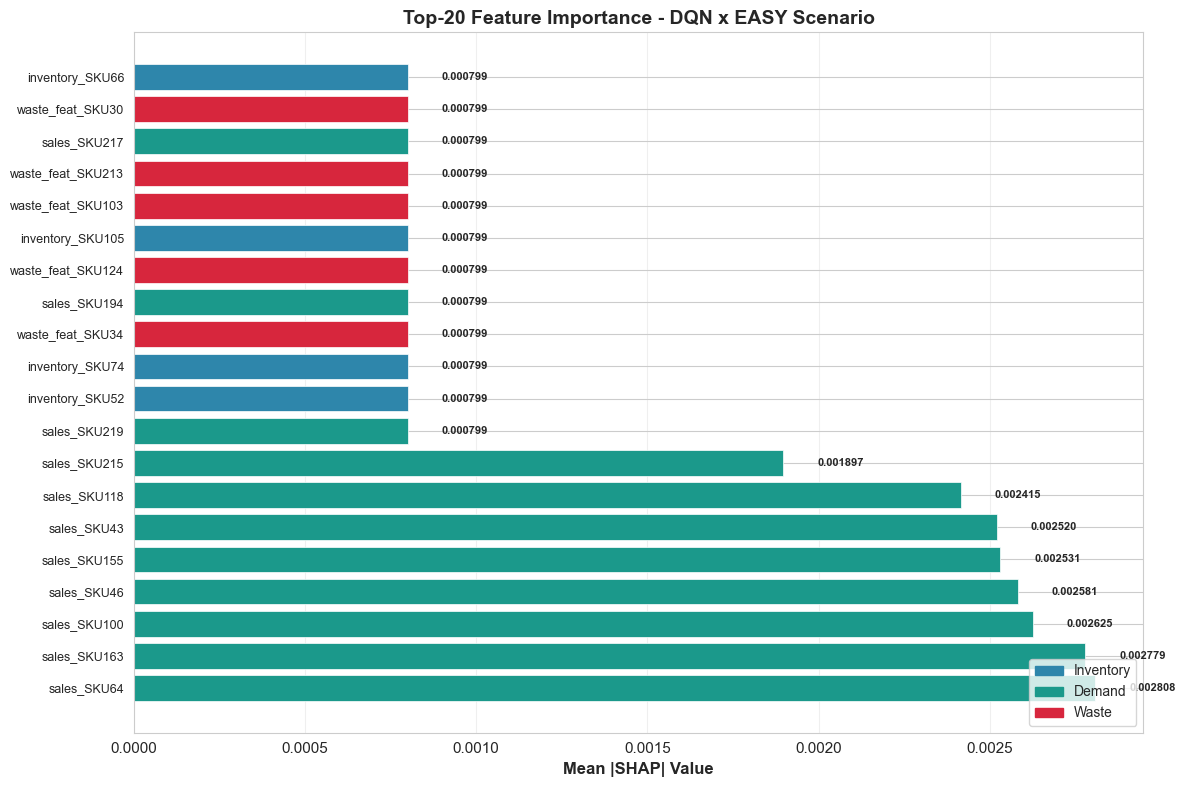


Plot: DQN x MEDIUM
   Saved: png/top20_shap_DQN_MEDIUM.png


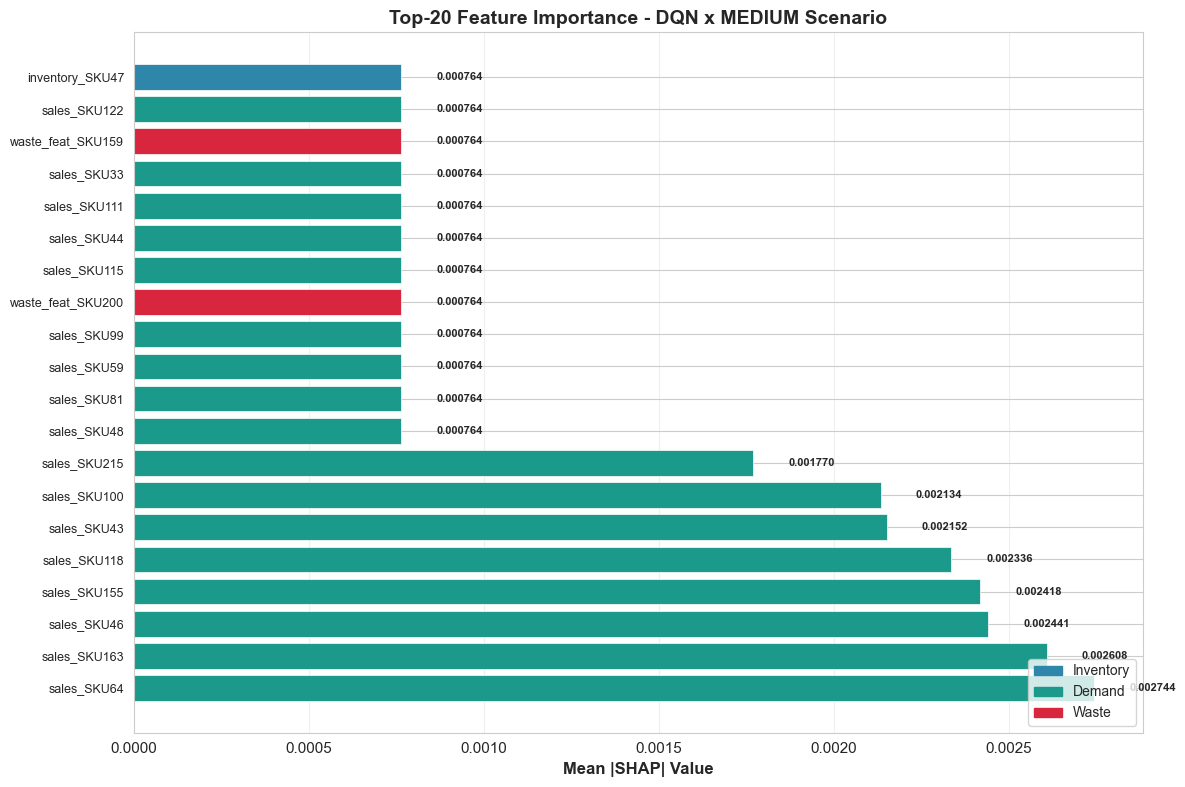


Plot: DQN x HARD
   Saved: png/top20_shap_DQN_HARD.png


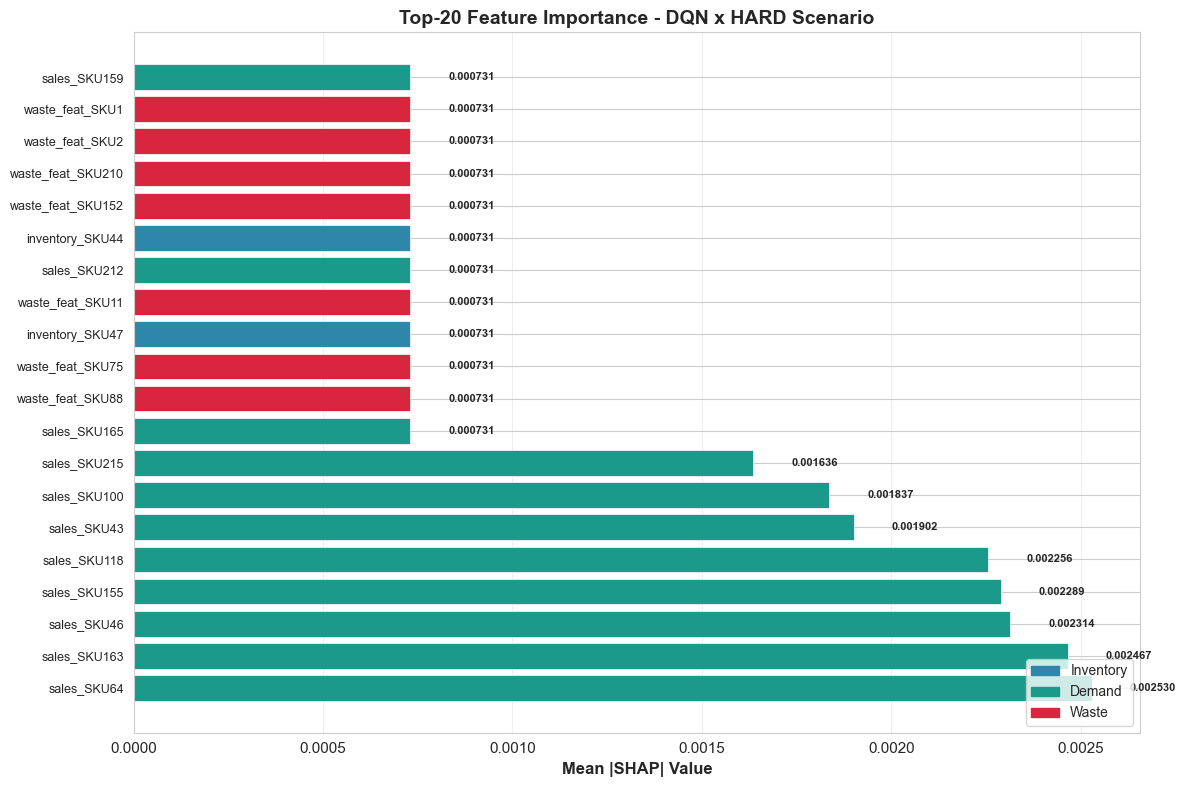


Plot: A2C_mod x EASY
   Saved: png/top20_shap_A2C_mod_EASY.png


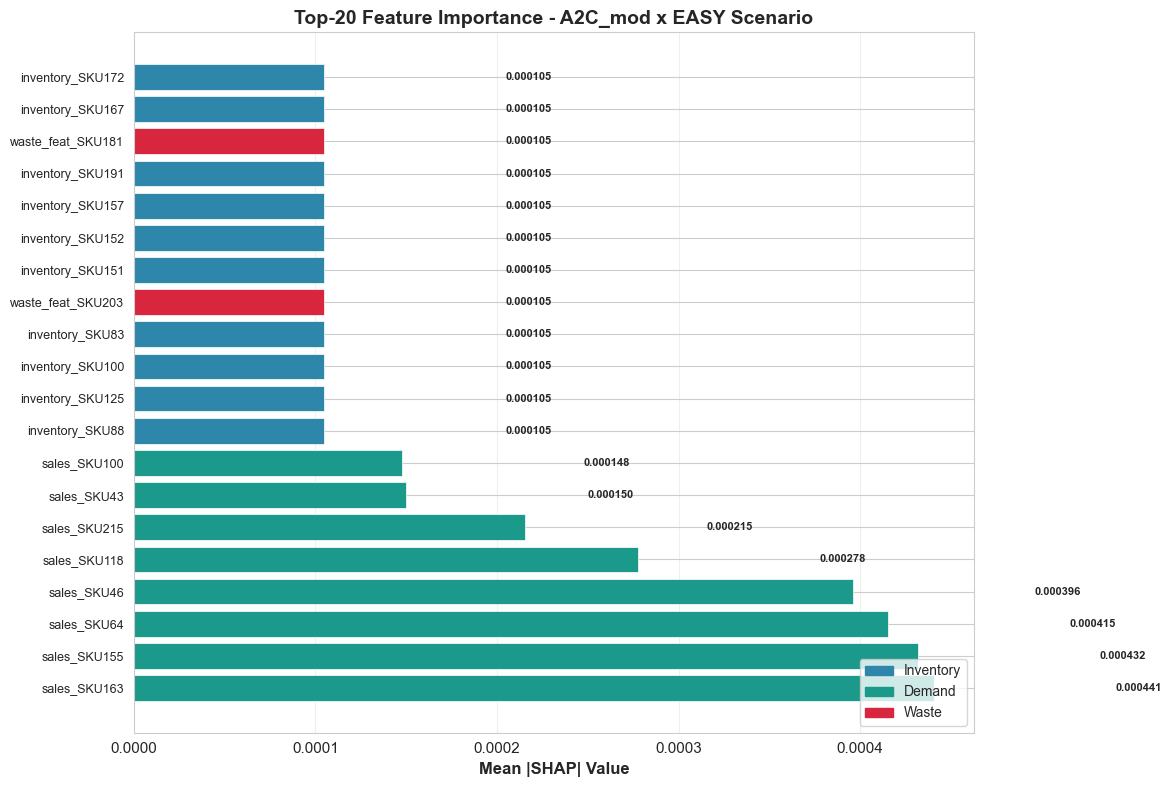


Plot: A2C_mod x MEDIUM
   Saved: png/top20_shap_A2C_mod_MEDIUM.png


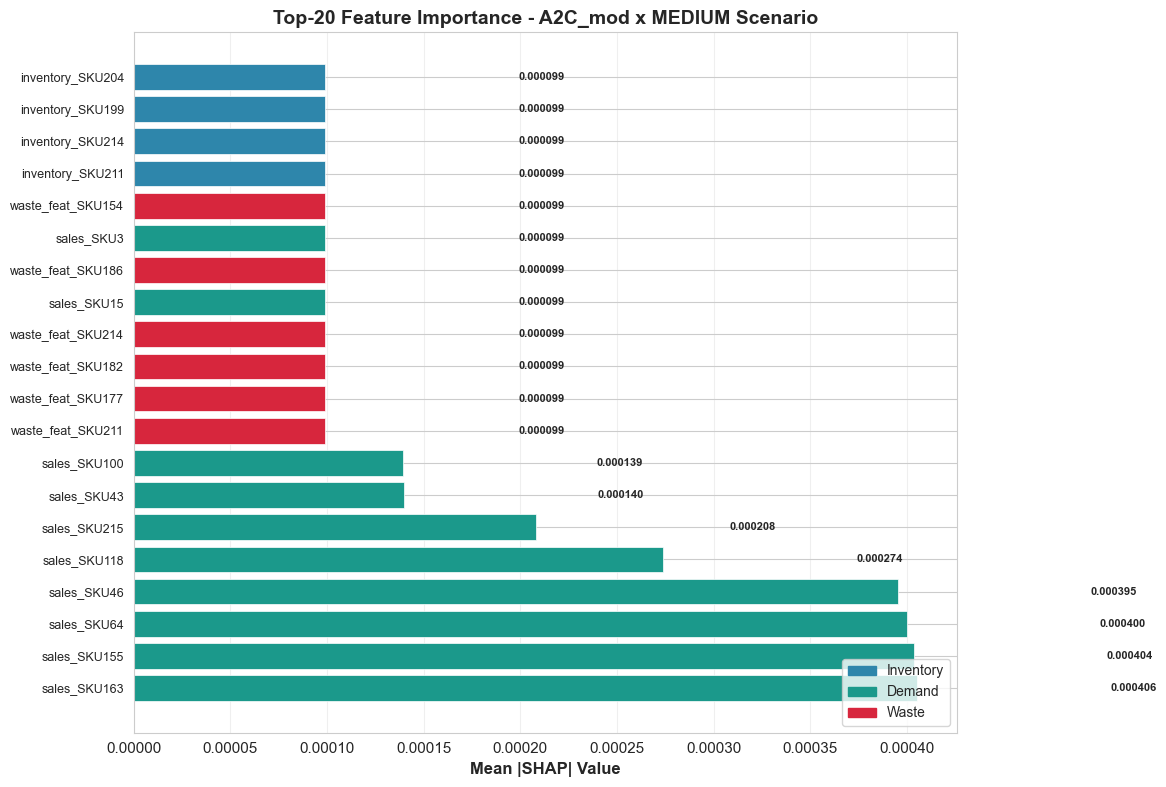


Plot: A2C_mod x HARD
   Saved: png/top20_shap_A2C_mod_HARD.png


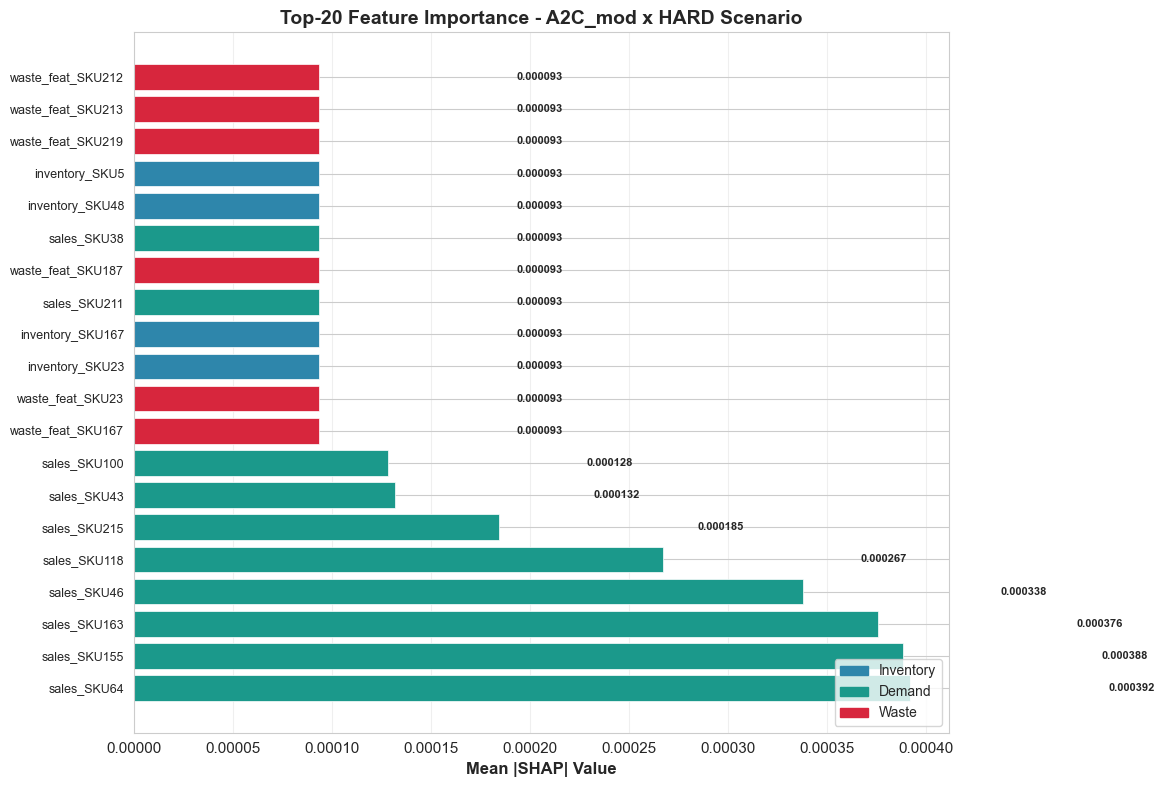

In [17]:
# ============================================================
# Plot Top-k SHAP Feature Importance
# ============================================================
COLOR_MAP = {
    'inventory': '#2E86AB',
    'sales':     '#1B998B',
    'waste_feat': '#D7263D',
}
GROUP_LABELS = {
    'inventory': 'Inventory',
    'sales':     'Demand',
    'waste_feat': 'Waste',
}

def plot_topk_shap(agent_name, scenario_name, top_k=20, save_path=None):
    data = shap_results_660[agent_name][scenario_name]
    importance = data['shap_importance']
    sorted_idx = np.argsort(importance)[::-1][:top_k]
    top_names = [FEATURE_NAMES_660[i] for i in sorted_idx]
    top_imp   = [importance[i] for i in sorted_idx]
    top_colors = [COLOR_MAP[FEATURE_GROUPS_660[i]] for i in sorted_idx]

    fig, ax = plt.subplots(figsize=(12, 8))
    y_pos = np.arange(len(top_names))
    bars = ax.barh(y_pos, top_imp[::-1], color=top_colors[::-1], edgecolor='white', linewidth=0.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_names[::-1], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP| Value', fontsize=12, fontweight='bold')
    ax.set_title(f'Top-{top_k} Feature Importance - {agent_name} x {scenario_name} Scenario',
                 fontsize=14, fontweight='bold')

    for i, (val, bar) in enumerate(zip(top_imp[::-1], bars)):
        if val > 0:
            ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2,
                    f'{val:.6f}', va='center', fontsize=8, fontweight='bold')

    legend_patches = [
        mpatches.Patch(color=COLOR_MAP['inventory'], label='Inventory'),
        mpatches.Patch(color=COLOR_MAP['sales'], label='Demand'),
        mpatches.Patch(color=COLOR_MAP['waste_feat'], label='Waste'),
    ]
    ax.legend(handles=legend_patches, fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'   Saved: {save_path}')
    plt.show()
    plt.close()

os.makedirs('png', exist_ok=True)
for agent_name in ['DQN', 'A2C_mod']:
    for sc in SCENARIO_ORDER:
        print(f'\nPlot: {agent_name} x {sc}')
        plot_topk_shap(
            agent_name, sc,
            top_k=20,
            save_path=f'png/top20_shap_{agent_name}_{sc}.png'
        )

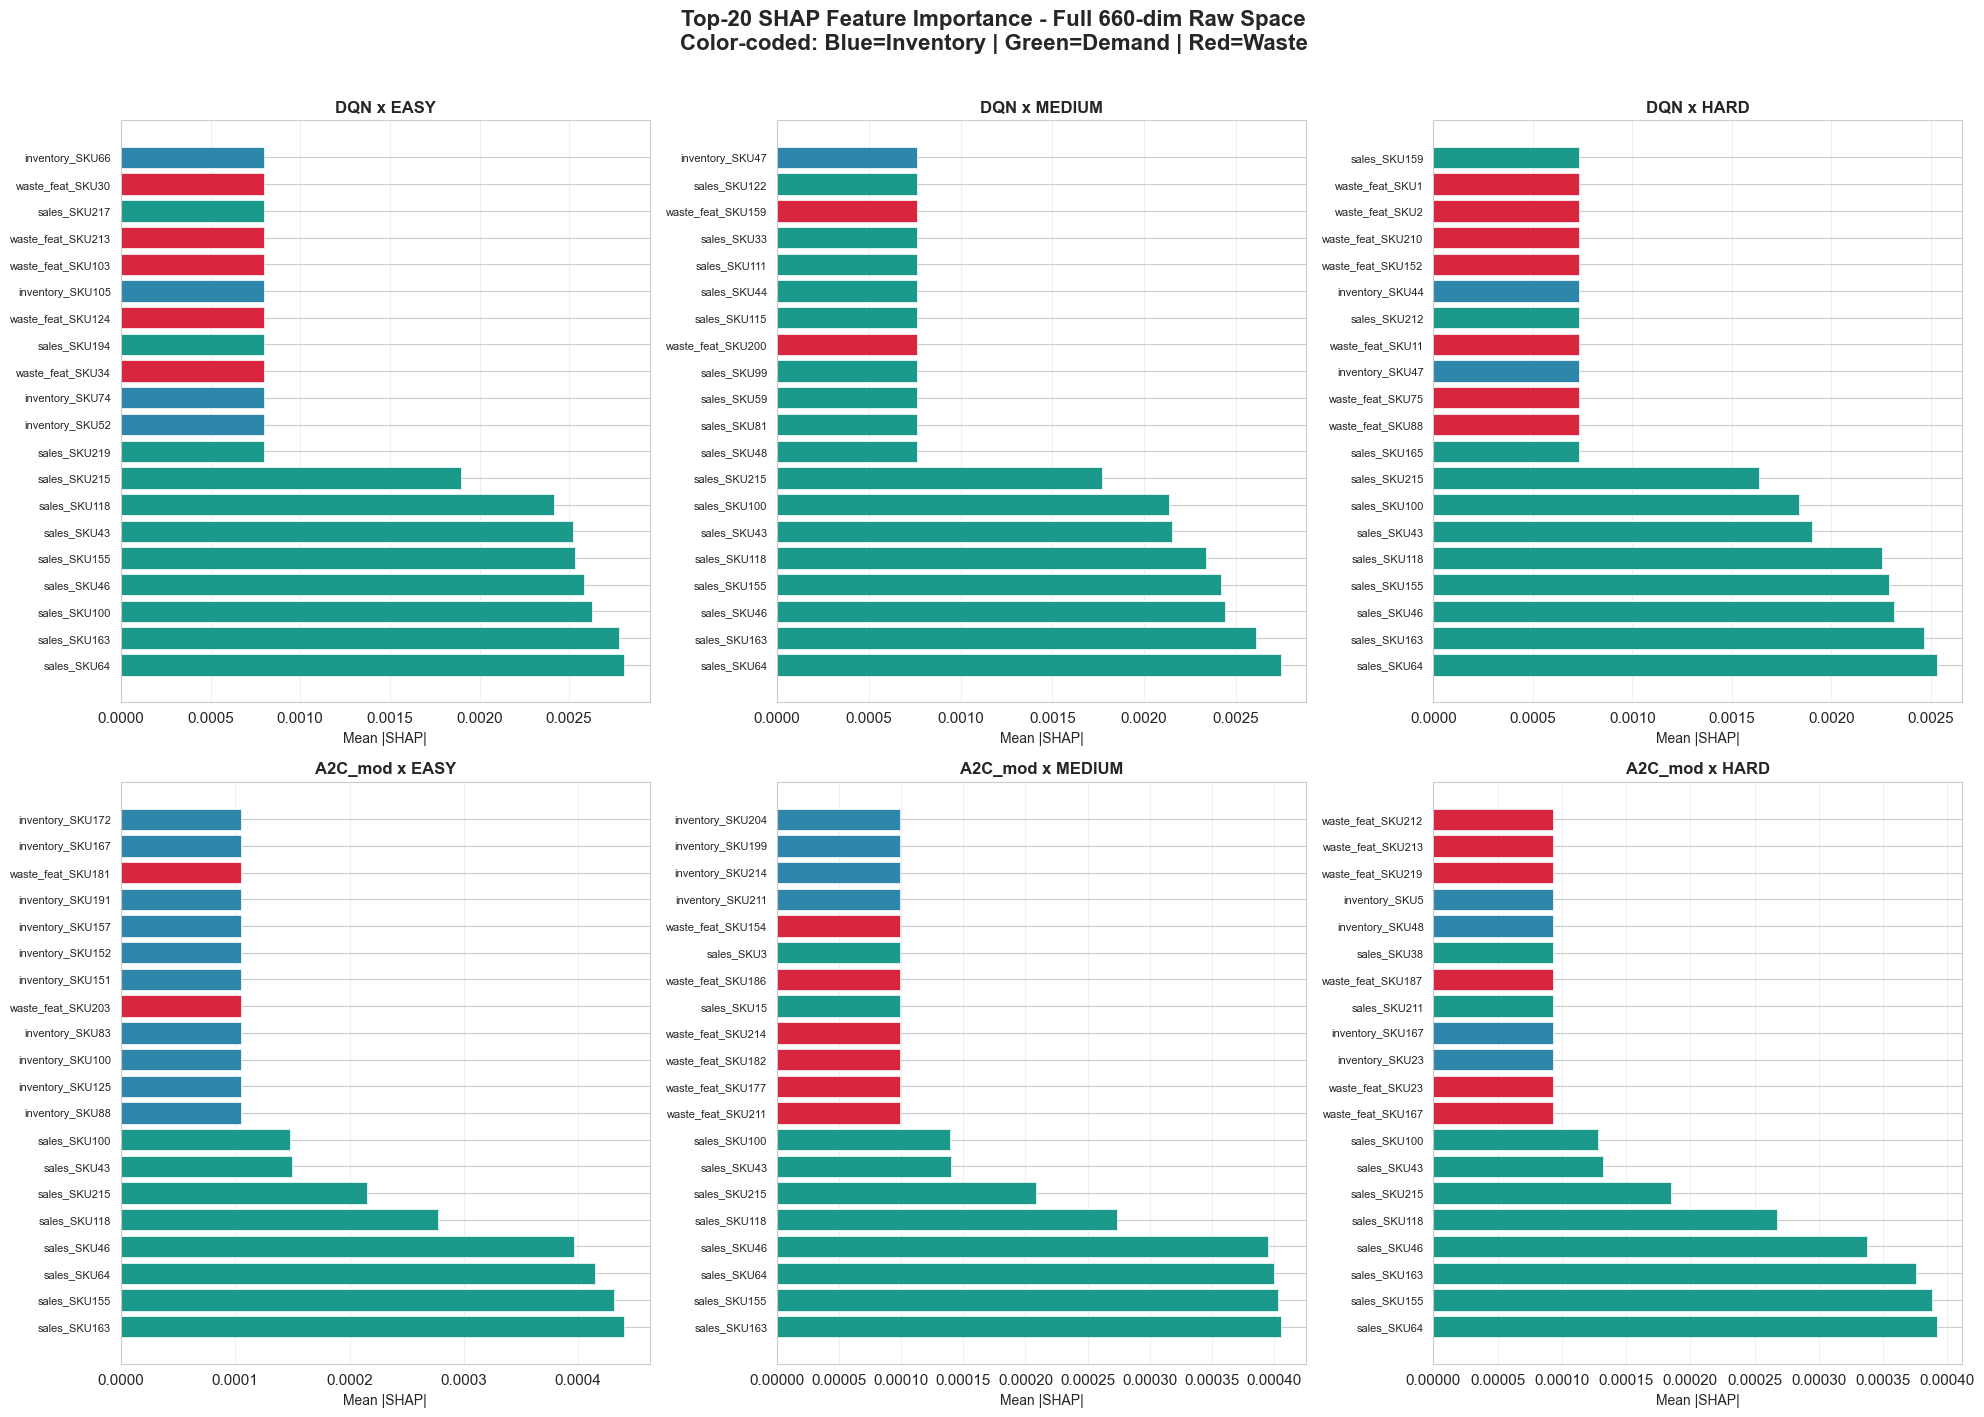

OK Combined grid saved: png/top20_shap_combined_grid.png


In [18]:
# ============================================================
# Combined Figure: All 6 configs in one grid
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Top-20 SHAP Feature Importance - Full 660-dim Raw Space\n'
             'Color-coded: Blue=Inventory | Green=Demand | Red=Waste',
             fontsize=16, fontweight='bold', y=1.01)

for row, agent_name in enumerate(['DQN', 'A2C_mod']):
    for col, sc in enumerate(SCENARIO_ORDER):
        ax = axes[row, col]
        data = shap_results_660[agent_name][sc]
        importance = data['shap_importance']

        top_k = 20
        sorted_idx = np.argsort(importance)[::-1][:top_k]
        top_names = [FEATURE_NAMES_660[i] for i in sorted_idx]
        top_imp   = [importance[i] for i in sorted_idx]
        top_colors = [COLOR_MAP[FEATURE_GROUPS_660[i]] for i in sorted_idx]

        y_pos = np.arange(len(top_names))
        ax.barh(y_pos, top_imp[::-1], color=top_colors[::-1], edgecolor='white', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_names[::-1], fontsize=8)
        ax.invert_yaxis()
        ax.set_title(f'{agent_name} x {sc}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Mean |SHAP|', fontsize=10)
        ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('png/top20_shap_combined_grid.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('OK Combined grid saved: png/top20_shap_combined_grid.png')

---
## Step 7: Summary & Export
---

In [19]:
# ============================================================
# Summary Statistics: Macro vs Micro Comparison
# ============================================================
print('='*80)
print('TONG KET: PHAN TICH SHAP DA CAP DO')
print('='*80)
print()

for agent_name in ['DQN', 'A2C_mod']:
    print(f'--- Agent: {agent_name} ---')
    for sc in SCENARIO_ORDER:
        data = shap_results_660[agent_name][sc]
        imp = data['shap_importance']

        # Macro level
        macro_inv = np.mean(imp[:NUM_PRODUCTS])
        macro_sal = np.mean(imp[NUM_PRODUCTS:2*NUM_PRODUCTS])
        macro_was = np.mean(imp[2*NUM_PRODUCTS:])

        # Micro level: Top-5
        top5_idx = np.argsort(imp)[-5:][::-1]
        top5_names = [FEATURE_NAMES_660[i] for i in top5_idx]
        top5_vals  = [imp[i] for i in top5_idx]
        top5_groups = [FEATURE_GROUPS_660[i] for i in top5_idx]

        print(f'  Scenario: {sc}')
        print(f'    Macro |SHAP|: Inv={macro_inv:.6f} | Sal={macro_sal:.6f} | Was={macro_was:.6f}')
        print(f'    Macro Dominant: {FEATURES_MACRO[np.argmax([macro_inv, macro_sal, macro_was])]}')
        print(f'    Top-5 Micro:')
        for i, (name, val, grp) in enumerate(zip(top5_names, top5_vals, top5_groups), 1):
            print(f'      {i}. {name} ({val:.6f}) [{grp}]')
        print()

# Export to CSV
all_rows = []
for agent_name in ['DQN', 'A2C_mod']:
    for sc in SCENARIO_ORDER:
        data = shap_results_660[agent_name][sc]
        imp = data['shap_importance']
        for i in range(NUM_FEATURES):
            all_rows.append({
                'Agent': agent_name,
                'Scenario': sc,
                'FeatureIdx': i,
                'FeatureName': FEATURE_NAMES_660[i],
                'MacroGroup': FEATURE_GROUPS_660[i],
                'SKU_ID': FEATURE_SKU_IDS[i],
                'MeanAbsSHAP': imp[i],
            })

df_export = pd.DataFrame(all_rows)
df_export.to_csv('topk_shap_full_results_660.csv', index=False)
print('OK Full results exported to: topk_shap_full_results_660.csv')
print(f'   Shape: {df_export.shape}')

TONG KET: PHAN TICH SHAP DA CAP DO

--- Agent: DQN ---
  Scenario: EASY
    Macro |SHAP|: Inv=0.000799 | Sal=0.000862 | Was=0.000799
    Macro Dominant: sales
    Top-5 Micro:
      1. sales_SKU64 (0.002808) [sales]
      2. sales_SKU163 (0.002779) [sales]
      3. sales_SKU100 (0.002625) [sales]
      4. sales_SKU46 (0.002581) [sales]
      5. sales_SKU155 (0.002531) [sales]

  Scenario: MEDIUM
    Macro |SHAP|: Inv=0.000764 | Sal=0.000821 | Was=0.000764
    Macro Dominant: sales
    Top-5 Micro:
      1. sales_SKU64 (0.002744) [sales]
      2. sales_SKU163 (0.002608) [sales]
      3. sales_SKU46 (0.002441) [sales]
      4. sales_SKU155 (0.002418) [sales]
      5. sales_SKU118 (0.002336) [sales]

  Scenario: HARD
    Macro |SHAP|: Inv=0.000731 | Sal=0.000782 | Was=0.000731
    Macro Dominant: sales
    Top-5 Micro:
      1. sales_SKU64 (0.002530) [sales]
      2. sales_SKU163 (0.002467) [sales]
      3. sales_SKU46 (0.002314) [sales]
      4. sales_SKU155 (0.002289) [sales]
      5. s

---
## Bang so sanh 2 cap SHAP Analysis (Tong hop)
---

| SHAP Level | Input Features | Muc dich | Pham vi giai thich |
| :--- | :--- | :--- | :--- |
| **Aggregated SHAP** | 3 macro features (Inventory, Demand, Waste) | Khung dinh huong chien luoc cho nha quan tri | System-level operational drivers (Nhom nao?) |
| **Top-k Feature SHAP** | 660 raw features (SKU-level) | Xac dinh chinh xac SKU/bien he thong dan dat quyet dinh | Product-level decision drivers (SKU nao?) |

> **Ket luan**: 
> - Macro SHAP cho biet **nhom feature nao** quan trong (vd: Inventory dan dat quyet dinh trong EASY scenario)
> - Micro Top-k SHAP cho biet **SKU cu the nao** trong nhom do thuc su co anh huong lon nhat
> - Hai cap do bo sung cho nhau, khong loai tru nhau. Viec giu lai ca hai giup nghien cuu vua co **tinh chien luoc** vua co **tinh minh bach van hanh**.